In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
import pickle

train_df = pd.read_csv('customer_churn_dataset-training-master.csv')
test_df = pd.read_csv('customer_churn_dataset-testing-master.csv')

df = pd.concat([train_df, test_df], ignore_index=True)
print(df.shape)

(505207, 12)


(505207, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505207 entries, 0 to 505206
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         505206 non-null  float64
 1   Age                505206 non-null  float64
 2   Gender             505206 non-null  object 
 3   Tenure             505206 non-null  float64
 4   Usage Frequency    505206 non-null  float64
 5   Support Calls      505206 non-null  float64
 6   Payment Delay      505206 non-null  float64
 7   Subscription Type  505206 non-null  object 
 8   Contract Length    505206 non-null  object 
 9   Total Spend        505206 non-null  float64
 10  Last Interaction   505206 non-null  float64
 11  Churn              505206 non-null  float64
dtypes: float64(9), object(3)
memory usage: 46.3+ MB
CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1

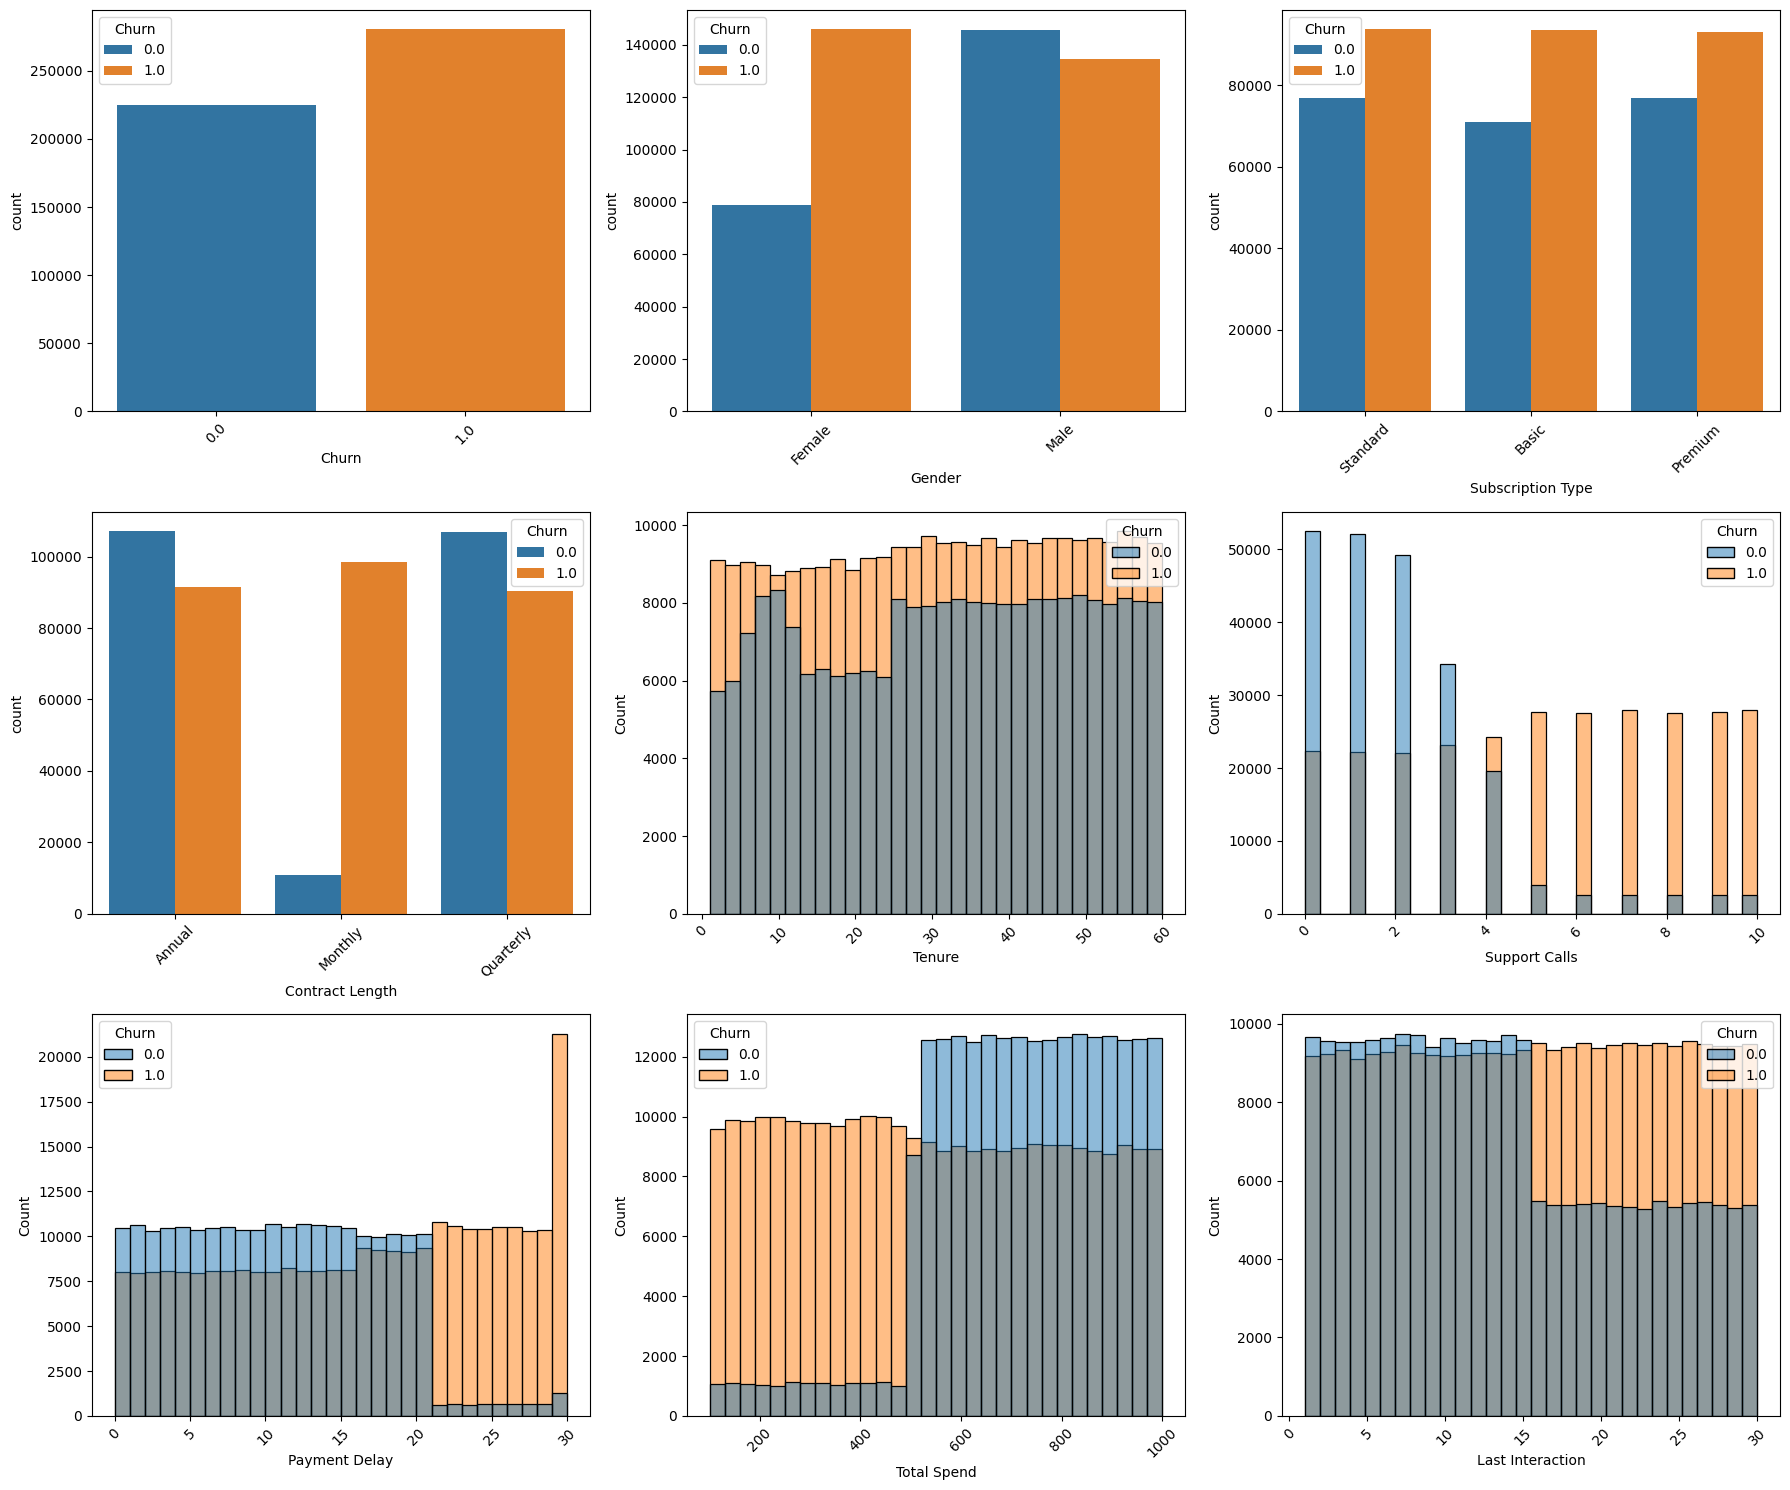

In [2]:
print(df.shape)
df.info()
df.describe()
print(df.isnull().sum())
print(df['Churn'].value_counts())

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
sns.countplot(x='Churn', hue='Churn', data=df, ax=axes[0,0])
sns.countplot(x='Gender', hue='Churn', data=df, ax=axes[0,1])
sns.countplot(x='Subscription Type', hue='Churn', data=df, ax=axes[0,2])
sns.countplot(x='Contract Length', hue='Churn', data=df, ax=axes[1,0])
sns.histplot(data=df, x='Tenure', hue='Churn', bins=30, ax=axes[1,1])
sns.histplot(data=df, x='Support Calls', hue='Churn', bins=30, ax=axes[1,2])
sns.histplot(data=df, x='Payment Delay', hue='Churn', bins=30, ax=axes[2,0])
sns.histplot(data=df, x='Total Spend', hue='Churn', bins=30, ax=axes[2,1])
sns.histplot(data=df, x='Last Interaction', hue='Churn', bins=30, ax=axes[2,2])
for ax in axes.flatten():
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [3]:
df = df.drop(['CustomerID'], axis=1)
df = df.dropna()
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df = pd.get_dummies(df, columns=['Subscription Type', 'Contract Length'])
df = df.astype({col: int for col in df.select_dtypes(bool).columns})
df['Churn'] = df['Churn'].astype(int)
print(df.shape)
print(df.dtypes)

(505206, 15)
Age                           float64
Gender                          int64
Tenure                        float64
Usage Frequency               float64
Support Calls                 float64
Payment Delay                 float64
Total Spend                   float64
Last Interaction              float64
Churn                           int64
Subscription Type_Basic         int64
Subscription Type_Premium       int64
Subscription Type_Standard      int64
Contract Length_Annual          int64
Contract Length_Monthly         int64
Contract Length_Quarterly       int64
dtype: object


In [4]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"X_train: {X_train.shape}")
print(f"y_train:\n{pd.Series(y_train).value_counts()}")

X_train: (448862, 14)
y_train:
Churn
0    224431
1    224431
Name: count, dtype: int64


In [ ]:
lr = LogisticRegression(random_state=42, max_iter=1000, C=1, solver='liblinear')
rf = RandomForestClassifier(max_depth=10, min_samples_split=10, n_estimators=300, random_state=42)
xgb = XGBClassifier(random_state=42, eval_metric='logloss', n_estimators=300, learning_rate=0.1, max_depth=7)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)

models = ['Logistic Regression', 'Random Forest', 'XGBoost']
predictions = [lr_pred, rf_pred, xgb_pred]

for model, pred in zip(models, predictions):
    print(f"\nModel: {model}")
    print(f"Accuracy : {accuracy_score(y_test, pred):.4f}")
    print(f"F1 Score : {f1_score(y_test, pred):.4f}")
    print(f"ROC AUC  : {roc_auc_score(y_test, pred):.4f}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_test, pred)}\n")


Model: Logistic Regression
Accuracy : 0.8455
F1 Score : 0.8582
ROC AUC  : 0.8459
Confusion Matrix:
[[38214  6767]
 [ 8841 47220]]


Model: Random Forest
Accuracy : 0.9246
F1 Score : 0.9351
ROC AUC  : 0.9180
Confusion Matrix:
[[38558  6423]
 [ 1193 54868]]


Model: XGBoost
Accuracy : 0.9331
F1 Score : 0.9428
ROC AUC  : 0.9254
Confusion Matrix:
[[38493  6488]
 [  275 55786]]



In [6]:
with open('churn_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model and scaler saved!")

Model and scaler saved!
